### Algerian forest fire project - Model training and regression models

in this part we train a model using linear, ridge, lasso, ElasticNet and use ridgecv, lassocv, ElasticNetcv for validation

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [49]:
df=pd.read_csv("Algerian_forest_fire_cleaned_dataset.csv")

In [50]:
df.head()

,Unnamed: 0,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [51]:
df.drop(['Unnamed: 0','day','month','year'],axis=1,inplace=True)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  244 non-null    int64  
 1   RH           244 non-null    int64  
 2   Ws           244 non-null    int64  
 3   Rain         244 non-null    float64
 4   FFMC         244 non-null    float64
 5   DMC          244 non-null    float64
 6   DC           244 non-null    float64
 7   ISI          244 non-null    float64
 8   BUI          244 non-null    float64
 9   FWI          244 non-null    float64
 10  Classes      244 non-null    object 
 11  Region       244 non-null    int64  
dtypes: float64(7), int64(4), object(1)
memory usage: 23.0+ KB


In [53]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),0,1)
df['Classes']=df['Classes'].astype(int)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  244 non-null    int64  
 1   RH           244 non-null    int64  
 2   Ws           244 non-null    int64  
 3   Rain         244 non-null    float64
 4   FFMC         244 non-null    float64
 5   DMC          244 non-null    float64
 6   DC           244 non-null    float64
 7   ISI          244 non-null    float64
 8   BUI          244 non-null    float64
 9   FWI          244 non-null    float64
 10  Classes      244 non-null    int64  
 11  Region       244 non-null    int64  
dtypes: float64(7), int64(5)
memory usage: 23.0 KB


In [55]:
X=df.drop('FWI',axis=1)
y=df['FWI']

In [56]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)
X_train.shape,X_test.shape

((183, 11), (61, 11))

In [57]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.664492,-0.249312,-0.375047,0.703238,0.485379,0.374673,0.609525,0.458575,0.512818,0.256099
RH,-0.664492,1.000000,0.235766,0.262550,-0.637201,-0.398168,-0.215075,-0.694976,-0.344365,-0.429397,-0.397053
Ws,-0.249312,0.235766,1.000000,0.262759,-0.169489,-0.013533,0.073923,0.015384,0.022529,-0.078171,-0.229797
Rain,-0.375047,0.262550,0.262759,1.000000,-0.585018,-0.291338,-0.296114,-0.353219,-0.301347,-0.394262,-0.096985
FFMC,0.703238,-0.637201,-0.169489,-0.585018,1.000000,0.602278,0.508348,0.744270,0.592841,0.774398,0.237434
DMC,0.485379,-0.398168,-0.013533,-0.291338,0.602278,1.000000,0.877045,0.652894,0.981876,0.580530,0.197489
DC,0.374673,-0.215075,0.073923,-0.296114,0.508348,0.877045,1.000000,0.496563,0.941248,0.501279,-0.079217
ISI,0.609525,-0.694976,0.015384,-0.353219,0.744270,0.652894,0.496563,1.000000,0.624038,0.744568,0.267027
BUI,0.458575,-0.344365,0.022529,-0.301347,0.592841,0.981876,0.941248,0.624038,1.000000,0.583094,0.092548
Classes,0.512818,-0.429397,-0.078171,-0.394262,0.774398,0.580530,0.501279,0.744568,0.583094,1.000000,0.158763


#### check for multi-collinearity

<Axes: >

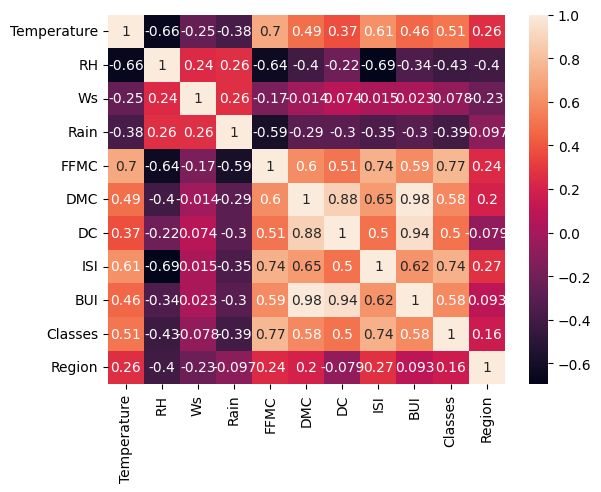

In [58]:
plt.Figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [59]:
def correlation(dataset,threshold):
    col_corr=set()
    cor_matrix=dataset.corr()
    for i in range(len(cor_matrix.columns)):
        for j in range(i):
            if abs(cor_matrix.iloc[i,j])>threshold:
                colname=cor_matrix.columns[i]
                col_corr.add(colname)
    return col_corr
        

In [60]:
#threshould is defined by domain experts
corr_features=correlation(X_train,0.85)

In [61]:
corr_features

{'BUI', 'DC'}

In [62]:
# drop features when correlation is more than threshold
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)


In [63]:
X_train.shape,X_test.shape

((183, 9), (61, 9))

In [64]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

box plot tounderstand the effect of standerd scaling

Text(0.5, 1.0, 'X_train after scaling')

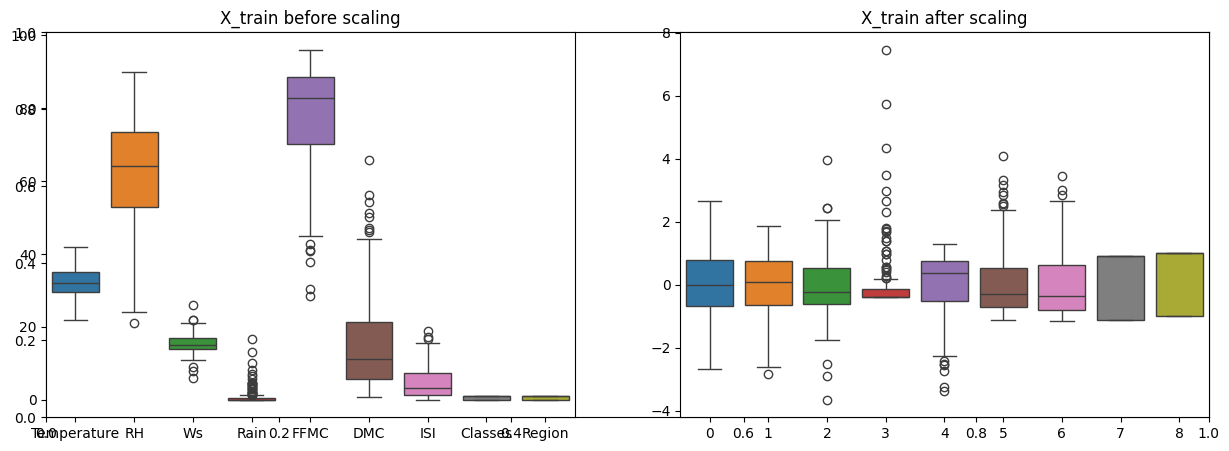

In [75]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("X_train before scaling")
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("X_train after scaling")


### Linear regression model

mean absolute error: 0.6246056520830193
r2 score: 0.9883487754859013


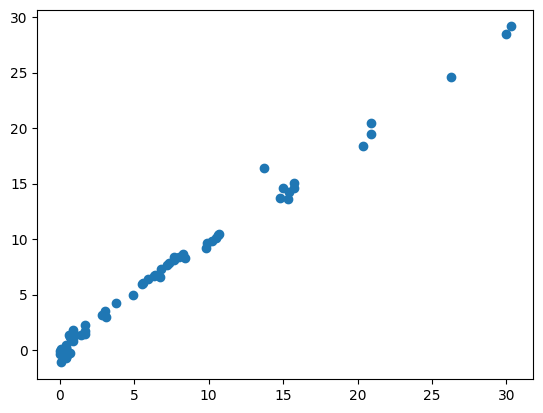

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
lin_reg=LinearRegression()
lin_reg.fit(X_train_scaled,y_train)
y_pred=lin_reg.predict(X_test_scaled)
mae_linreg=mean_absolute_error(y_test,y_pred)
print("mean absolute error:",mae_linreg)
score_linreg=r2_score(y_test,y_pred)
print("r2 score:",score_linreg)
plt.scatter(y_test,y_pred)

### Ridge regression model

mean absolute error: 0.6475053069008498
r2 score: 0.9876551758965115


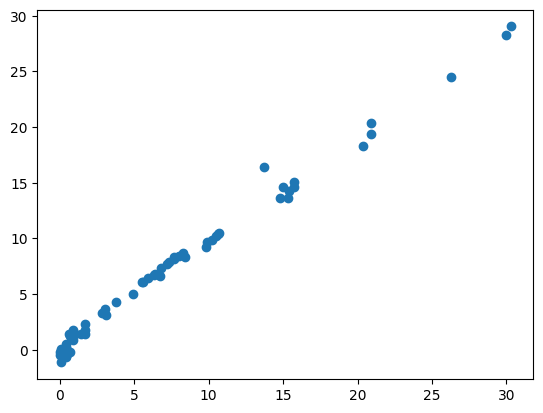

In [82]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae_ridge=mean_absolute_error(y_test,y_pred)
print("mean absolute error:",mae_ridge)
score_ridge=r2_score(y_test,y_pred)
print("r2 score:",score_ridge)
plt.scatter(y_test,y_pred)

### Lasso regression model


mean absolute error: 1.2335177755374633
r2 score: 0.9490173626264782


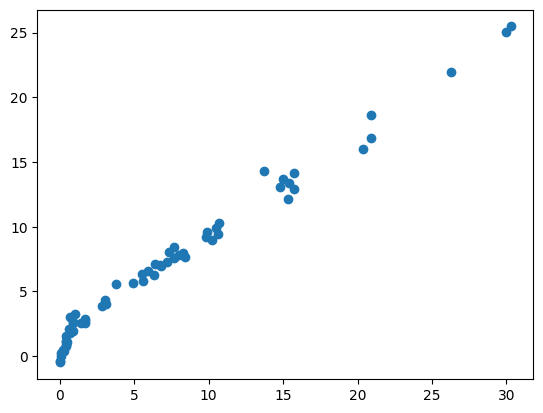

In [83]:
from sklearn.linear_model import Lasso
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
mae_lasso=mean_absolute_error(y_test,y_pred)
print("mean absolute error:",mae_lasso)
score_lasso=r2_score(y_test,y_pred)
print("r2 score:",score_lasso)
plt.scatter(y_test,y_pred)

### ElasticNet Regression model

mean absolute error: 1.920435746035084
r2 score: 0.8741644418289544


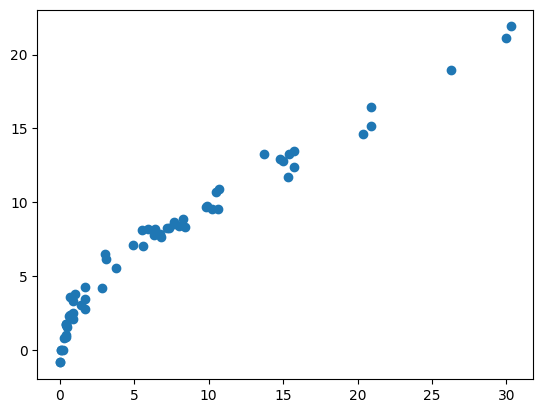

In [84]:
from sklearn.linear_model import ElasticNet
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mae_elastic=mean_absolute_error(y_test,y_pred)
print("mean absolute error:",mae_elastic)
score_elastic=r2_score(y_test,y_pred)
print("r2 score:",score_elastic)
plt.scatter(y_test,y_pred)

### cross validation using Ridge

mean absolute error: 0.6475053069008498
r2 score: 0.9876551758965115


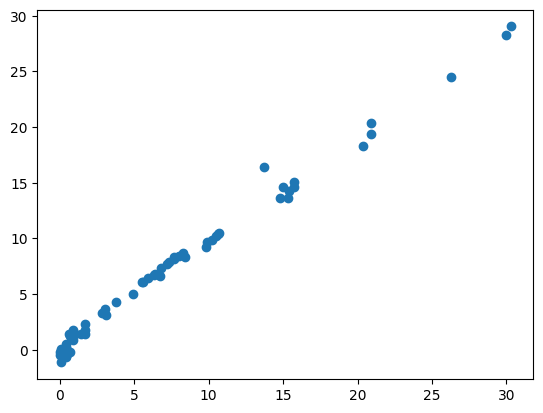

In [89]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
mae_ridgecv=mean_absolute_error(y_test,y_pred)
print("mean absolute error:",mae_ridgecv)
score_ridgecv=r2_score(y_test,y_pred)
print("r2 score:",score_ridgecv)
plt.scatter(y_test,y_pred)


### cross validation using lasso

mean absolute error: 0.6598564610709932
r2 score: 0.987417219463372


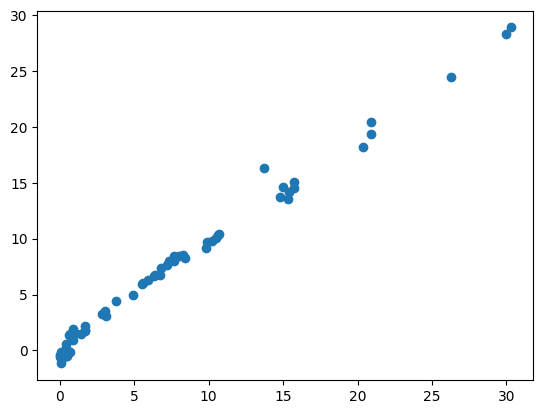

In [93]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV()
lassocv.fit(X_train_scaled,y_train)
y_pred=lassocv.predict(X_test_scaled)
mae_lassocv=mean_absolute_error(y_test,y_pred)
print("mean absolute error:",mae_lassocv)
score_lassocv=r2_score(y_test,y_pred)
print("r2 score:",score_lassocv)
plt.scatter(y_test,y_pred)

In [97]:
print(lassocv.coef_)
print(lassocv.alpha_)
print(lassocv.alphas_)
print(lassocv.mse_path_)

[-0.02915015 -0.          0.          0.         -0.53351023  3.63956971
  4.46004751  0.37244958 -0.39609952]
0.02672470212044074
[6.61991277 6.17375281 5.75766253 5.36961535 5.00772125 4.67021759
 4.35546056 4.06191709 3.78815748 3.53284834 3.29474619 3.07269132
 2.86560221 2.67247021 2.49235466 2.3243783  2.16772298 2.02162571
 1.8853749  1.75830694 1.63980294 1.52928571 1.42621697 1.33009472
 1.24045079 1.15684856 1.07888084 1.00616788 0.93835553 0.87511351
 0.81613379 0.7611291  0.70983155 0.66199128 0.61737528 0.57576625
 0.53696153 0.50077212 0.46702176 0.43554606 0.40619171 0.37881575
 0.35328483 0.32947462 0.30726913 0.28656022 0.26724702 0.24923547
 0.23243783 0.2167723  0.20216257 0.18853749 0.17583069 0.16398029
 0.15292857 0.1426217  0.13300947 0.12404508 0.11568486 0.10788808
 0.10061679 0.09383555 0.08751135 0.08161338 0.07611291 0.07098315
 0.06619913 0.06173753 0.05757663 0.05369615 0.05007721 0.04670218
 0.04355461 0.04061917 0.03788157 0.03532848 0.03294746 0.0307269

### cross validation using elasticnet

mean absolute error: 0.6789547147800585
r2 score: 0.9867594786757607


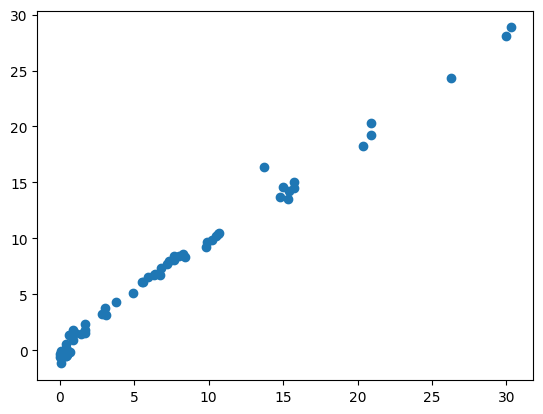

In [98]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV()
elasticcv.fit(X_train_scaled,y_train)
y_pred=elasticcv.predict(X_test_scaled)
mae_elasticcv=mean_absolute_error(y_test,y_pred)
print("mean absolute error:",mae_elasticcv)
score_elasticcv=r2_score(y_test,y_pred)
print("r2 score:",score_elasticcv)
plt.scatter(y_test,y_pred)

### observations

In [99]:
print("mae of linear regression:",mae_linreg)
print("mae of ridge regression:",mae_ridge)
print("mae of lasso regression:",mae_lasso)
print("mae of elasticnet regression:",mae_elastic)

mae of linear regression: 0.6246056520830193
mae of ridge regression: 0.6475053069008498
mae of lasso regression: 1.2335177755374633
mae of elasticnet regression: 1.920435746035084


In [101]:
print("r2 score of linear regression:",score_linreg)
print("r2 score of ridge regression:",score_ridge)
print("r2 score of lasso regression:",score_lasso)
print("r2 score of elasticnet regression:",score_elastic)


r2 score of linear regression: 0.9883487754859013
r2 score of ridge regression: 0.9876551758965115
r2 score of lasso regression: 0.9490173626264782
r2 score of elasticnet regression: 0.8741644418289544


from above numbers we have conclude that
linear regression model perform best for thos dataset and gives more accuracy

In [102]:
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [103]:
ridge

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [104]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))

here we created two pickle files

scaler.pkl for scaling

ridge.pkl for prediction

ridge is used for prediction because it give good accuracy